# NOTEBOOK3: Implementing LASSO

Generate data

In [1]:
import pandas as pd
import numpy as np

def generate_data(n_samples, n_features, noise):
    d = {}
    f1 = np.random.randn(n_samples)
    d["f1"] = f1
    for i in range(2, n_features + 1):
        alpha_i = np.random.randn()
        d[f"f{i}"] = alpha_i * d[f"f{i-1}"] + noise
    return pd.DataFrame(d)

data = generate_data(150, 5, 0.2)
data.head()




,f1,f2,f3,f4,f5
0,-0.441936,-0.543890,0.246154,0.496625,-0.016576
1,0.457410,0.969936,0.117692,0.341823,0.050932
2,-0.064005,0.092263,0.192171,0.431573,0.011793
3,-0.694665,-0.969296,0.282254,0.540127,-0.035547
4,0.657432,1.306624,0.089121,0.307394,0.065947


Random forest + SHAP

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import shap

X = data.drop("f5", axis=1)
y = data["f5"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = RandomForestRegressor(random_state=55)
model.fit(train_X, train_y)

preds = model.predict(val_X)
mae = mean_absolute_error(val_y, preds)
mae


0.0040968212141553155

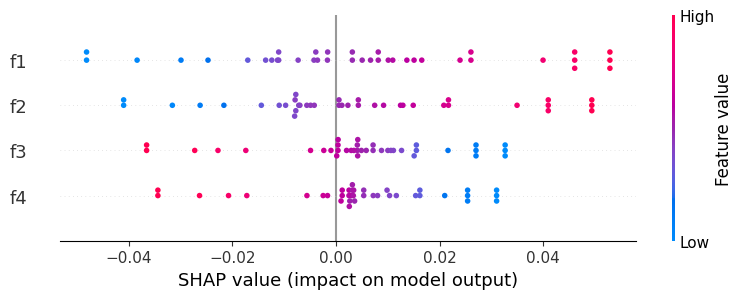

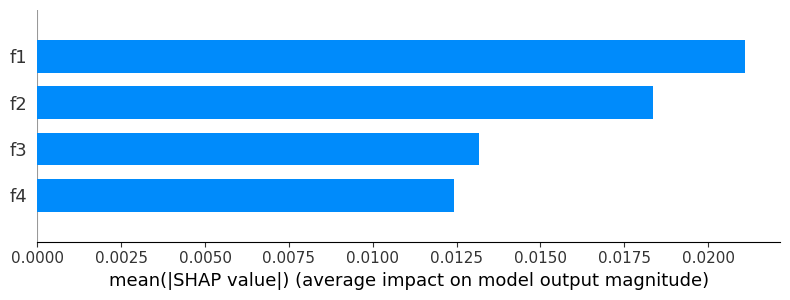

In [3]:
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(val_X)
shap.summary_plot(shap_values, val_X)
shap.summary_plot(shap_values, val_X, plot_type="bar")

decorrelated data  with f6 useless

In [4]:
d = {}
d["f1"] = np.random.randn(150)
for i in range(2, 6):
    d[f"f{i}"] = np.random.randn(150)
d["f6"] = np.random.randn(150)
df = pd.DataFrame(d)

X = df.drop("f6", axis=1)
y = df["f6"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
model = RandomForestRegressor(random_state=55)
model.fit(train_X, train_y)

preds = model.predict(val_X)
mae = mean_absolute_error(val_y, preds)
mae


0.8245199362153146

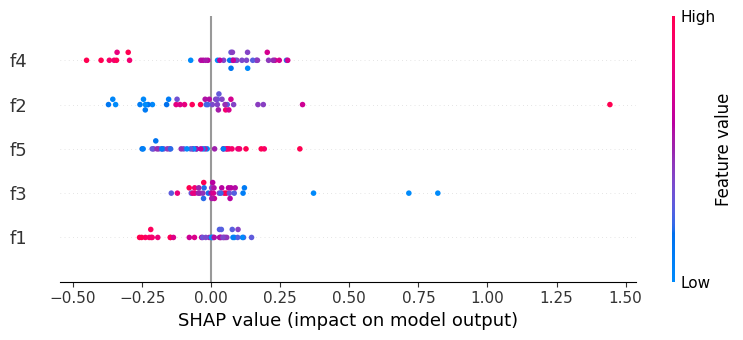

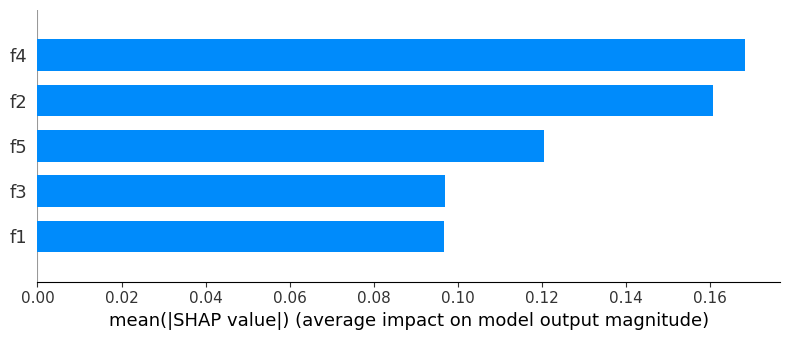

In [5]:
shap.initjs()
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(val_X)
shap.summary_plot(sv, val_X)
shap.summary_plot(sv, val_X, plot_type="bar")

eli5 ermutation matrix in this case

In [6]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(model, random_state=1).fit(val_X, val_y)
eli5.show_weights(perm, feature_names=val_X.columns.tolist())


Weight,Feature
0.1098 ± 0.2708,f2
0.0148 ± 0.1437,f1
0.0131 ± 0.1517,f5
-0.0335 ± 0.2552,f4
-0.1586 ± 0.1023,f3


LASSO L1 (Lasso) does feature selection, can set coeff exactly to 0. L2 (Ridge) shrinks coefficients but keeps them non-zero. ElasticNet balances both

In [7]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso = Pipeline([("scaler", StandardScaler()), ("m", Lasso(alpha=0.1))])
ridge = Pipeline([("scaler", StandardScaler()), ("m", Ridge(alpha=1.0))])
enet = Pipeline([("scaler", StandardScaler()), ("m", ElasticNet(alpha=0.1, l1_ratio=0.5))])

lasso.fit(train_X, train_y)
ridge.fit(train_X, train_y)
enet.fit(train_X, train_y)

lasso_coefs = dict(zip(train_X.columns, lasso.named_steps["m"].coef_))
ridge_coefs = dict(zip(train_X.columns, ridge.named_steps["m"].coef_))
enet_coefs = dict(zip(train_X.columns, enet.named_steps["m"].coef_))

lasso_coefs, ridge_coefs, enet_coefs


({'f1': np.float64(-0.017656605233669694),
  'f2': np.float64(0.0),
  'f3': np.float64(-0.01787806950721365),
  'f4': np.float64(-0.06299180630129214),
  'f5': np.float64(0.005628793686929653)},
 {'f1': np.float64(-0.08268143820818842),
  'f2': np.float64(0.07220581468550565),
  'f3': np.float64(-0.10132378614335998),
  'f4': np.float64(-0.15097971407274188),
  'f5': np.float64(0.10285797090836538)},
 {'f1': np.float64(-0.049635493955379174),
  'f2': np.float64(0.020736256577890962),
  'f3': np.float64(-0.05700675939943928),
  'f4': np.float64(-0.10321450935951507),
  'f5': np.float64(0.05140876678104145)})

almost like the permutations!

Let's try now with f6 depending almost entirely from f3

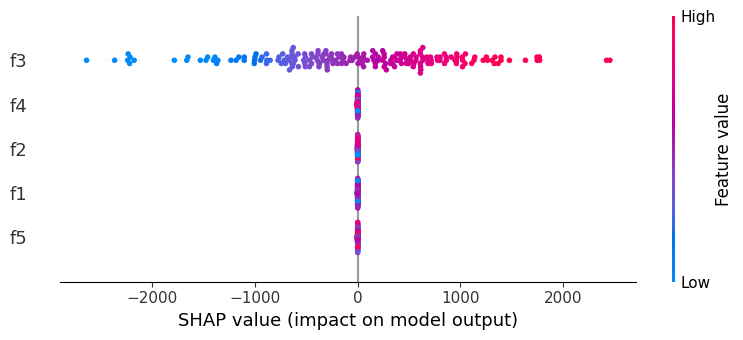

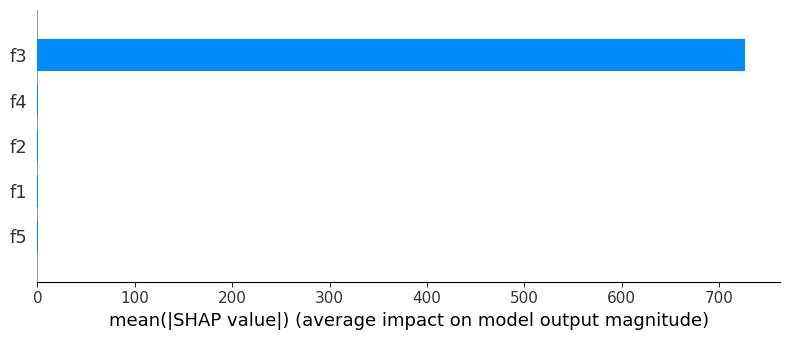

In [8]:
d = {}
d["f1"] = np.random.randn(800)
for i in range(2, 6):
    d[f"f{i}"] = np.random.randn(800)
d["f6"] = 0.5*d["f1"] + 2*d["f2"] + 1000*d["f3"] - 0.1*d["f4"]
df = pd.DataFrame(d)

X = df.drop("f6", axis=1)
y = df["f6"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
model = RandomForestRegressor(random_state=55)
model.fit(train_X, train_y)

shap.initjs()
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(val_X)
shap.summary_plot(sv, val_X)
shap.summary_plot(sv, val_X, plot_type="bar")


In [9]:
lasso = Pipeline([("scaler", StandardScaler()), ("m", Lasso(alpha=0.1))])
ridge = Pipeline([("scaler", StandardScaler()), ("m", Ridge(alpha=1.0))])
enet = Pipeline([("scaler", StandardScaler()), ("m", ElasticNet(alpha=0.1, l1_ratio=0.5))])

lasso.fit(train_X, train_y)
ridge.fit(train_X, train_y)
enet.fit(train_X, train_y)

lasso_coefs = dict(zip(train_X.columns, lasso.named_steps["m"].coef_))
ridge_coefs = dict(zip(train_X.columns, ridge.named_steps["m"].coef_))
enet_coefs = dict(zip(train_X.columns, enet.named_steps["m"].coef_))

lasso_coefs, ridge_coefs, enet_coefs

({'f1': np.float64(0.4380028628971045),
  'f2': np.float64(1.953594120106075),
  'f3': np.float64(1016.2650324400635),
  'f4': np.float64(-0.0),
  'f5': np.float64(-0.0)},
 {'f1': np.float64(0.5263842408039111),
  'f2': np.float64(2.0941863199623647),
  'f3': np.float64(1014.6702001666038),
  'f4': np.float64(-0.08495836419107526),
  'f5': np.float64(0.031995185787058976)},
 {'f1': np.float64(0.336778657980578),
  'f2': np.float64(3.2986270819996797),
  'f3': np.float64(967.8640074175227),
  'f4': np.float64(0.2878341434815129),
  'f5': np.float64(0.820732603331929)})

the 3 methods identify the weight of the coefficients

now with a cofounding variable

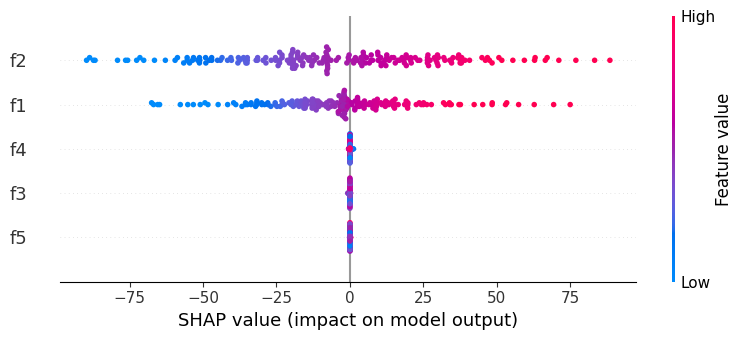

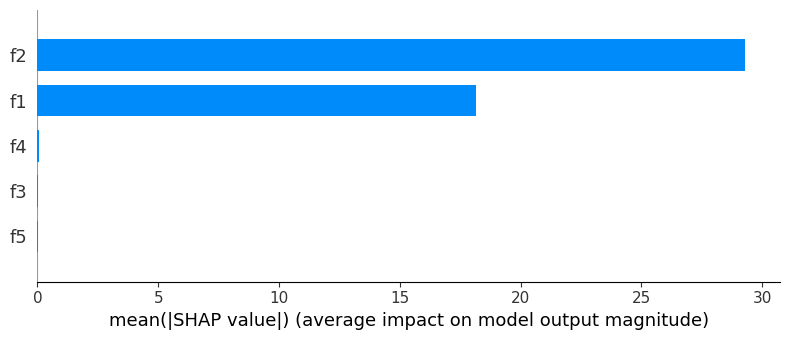

In [10]:
d = {}
d["f1"] = np.random.randn(800)
d["f2"] = d["f1"]*10 + np.random.randn(800)*0.1
for i in range(3, 6):
    d[f"f{i}"] = np.random.randn(800)
d["f6"] = 0.6*d["f1"] + 6*d["f2"] + 0.2*d["f3"] - 0.1*d["f4"] + 3

df = pd.DataFrame(d)

X = df.drop("f6", axis=1)
y = df["f6"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = RandomForestRegressor(random_state=55)
model.fit(train_X, train_y)

shap.initjs()
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(val_X)
shap.summary_plot(sv, val_X)
shap.summary_plot(sv, val_X, plot_type="bar")


In [11]:
lasso = Pipeline([("scaler", StandardScaler()), ("m", Lasso(alpha=0.1))])
ridge = Pipeline([("scaler", StandardScaler()), ("m", Ridge(alpha=1.0))])
enet = Pipeline([("scaler", StandardScaler()), ("m", ElasticNet(alpha=0.1, l1_ratio=0.5))])

lasso.fit(train_X, train_y)
ridge.fit(train_X, train_y)
enet.fit(train_X, train_y)

lasso_coefs = dict(zip(train_X.columns, lasso.named_steps["m"].coef_))
ridge_coefs = dict(zip(train_X.columns, ridge.named_steps["m"].coef_))
enet_coefs = dict(zip(train_X.columns, enet.named_steps["m"].coef_))

lasso_coefs, ridge_coefs, enet_coefs

({'f1': np.float64(59.502055414446126),
  'f2': np.float64(0.011748887720870134),
  'f3': np.float64(0.06699619651268705),
  'f4': np.float64(-0.0),
  'f5': np.float64(-0.0)},
 {'f1': np.float64(28.92576219530674),
  'f2': np.float64(30.64427479907343),
  'f3': np.float64(0.1815231590742639),
  'f4': np.float64(-0.09043832388418876),
  'f5': np.float64(-0.009223692718884314)},
 {'f1': np.float64(29.052481539230534),
  'f2': np.float64(29.057545700220373),
  'f3': np.float64(0.08978778873348565),
  'f4': np.float64(-0.0),
  'f5': np.float64(0.0)})

Lasso works immensely better at this

next steps: understand the way lasso and ridge work. why is it more useful for confounding variables? mathematically why is shapley not able to identify them? what offsets the results of lasso/ridge? 